In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
sys.path.append("..")

In [3]:
import torch
import matplotlib.pyplot as plt
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

from eqnet.models.sb_model import PhaseNet

In [6]:
model = PhaseNet()
model.load_state_dict(torch.load("../models/model_99.pth", map_location=torch.device('cpu'))["model"])
model.eval()

/var/folders/6k/s3t_029n0710wzkjtt75stch0000gp/T/ipykernel_39292/1504079355.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/m

PhaseNet(
  (backbone): UNet(
    (init_conv): Conv2d(3, 16, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
    (downs): ModuleList(
      (0): ModuleList(
        (0): ResnetBlock(
          (block1): Block(
            (proj): Conv2d(16, 16, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
            (norm): RMSNorm()
            (act): SiLU()
          )
          (block2): Block(
            (proj): Conv2d(16, 16, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
            (norm): RMSNorm()
            (act): SiLU()
          )
          (res_conv): Identity()
        )
        (1-2): 2 x Identity()
        (3): Sequential(
          (0): Rearrange('b c (h s1) (w s2) -> b (c s1 s2) h w', s1=1, s2=4)
          (1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        )
      )
      (1): ModuleList(
        (0): ResnetBlock(
          (block1): Block(
            (proj): Conv2d(16, 16, kernel_size=(1, 7), stride=(1, 1), padding=(0, 3))
            (norm): RMSNorm()
  

In [5]:
# x = torch.rand((5, 3, 4096, 1))
x = torch.rand((5, 3, 1, 2**10))
output = model(x)
output.keys()

dict_keys(['phase', 'event_center', 'event_time', 'polarity'])

In [6]:
output["phase"].shape

torch.Size([5, 3, 1, 1024])

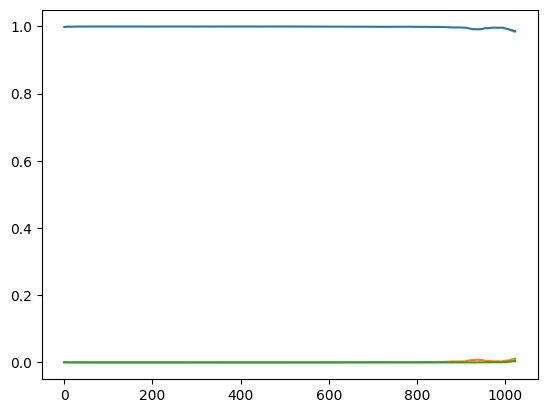

In [7]:
plt.plot(output["phase"][0, :, 0, :].T.detach().numpy())

In [7]:
client = Client("GFZ")

t = UTCDateTime("2007/01/02 05:48:50")
stream = client.get_waveforms(network="CX", station="PB01", location="*", channel="HH?", starttime=t-80, endtime=t+100)

In [46]:
2 ** 8

256

In [8]:
samples = 2 ** 14
model.in_samples = samples
model.pred_sample = (0, samples)

In [9]:
ann = model.annotate(stream)
ann

6 Trace(s) in Stream:
CX.PB01..PhaseNet_N            | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples
CX.PB01..PhaseNet_P            | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples
CX.PB01..PhaseNet_S            | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples
CX.PB01..PhaseNet_Polarity     | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples
CX.PB01..PhaseNet_Event center | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples
CX.PB01..PhaseNet_Event time   | 2007-01-02T05:47:29.998392Z - 2007-01-02T05:50:29.998392Z | 100.0 Hz, 18001 samples

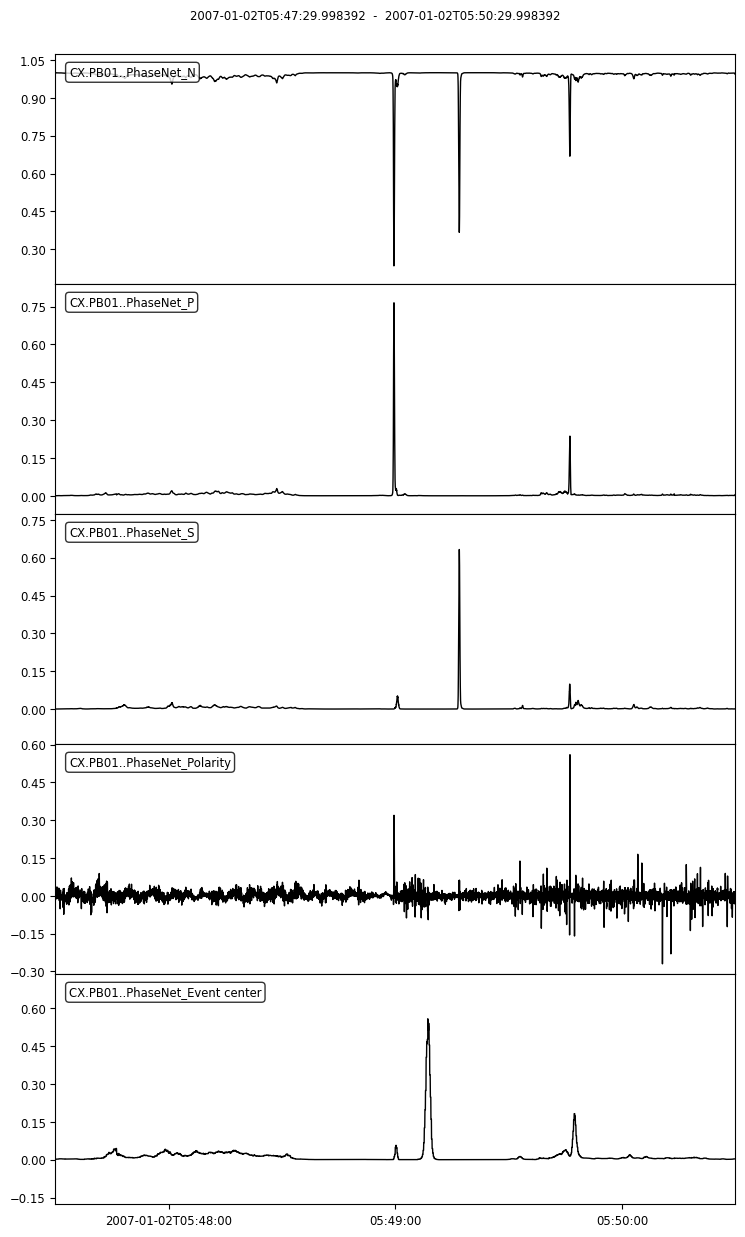

In [10]:
ann[:-1].plot(show=False)

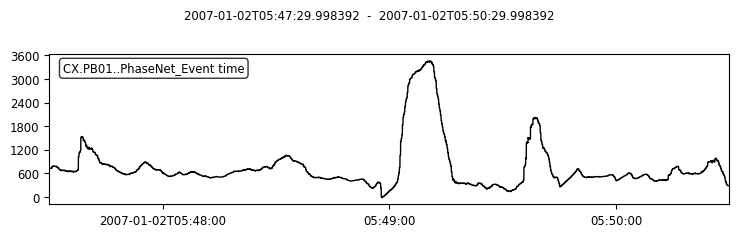

In [11]:
ann[-1].plot(show=False)

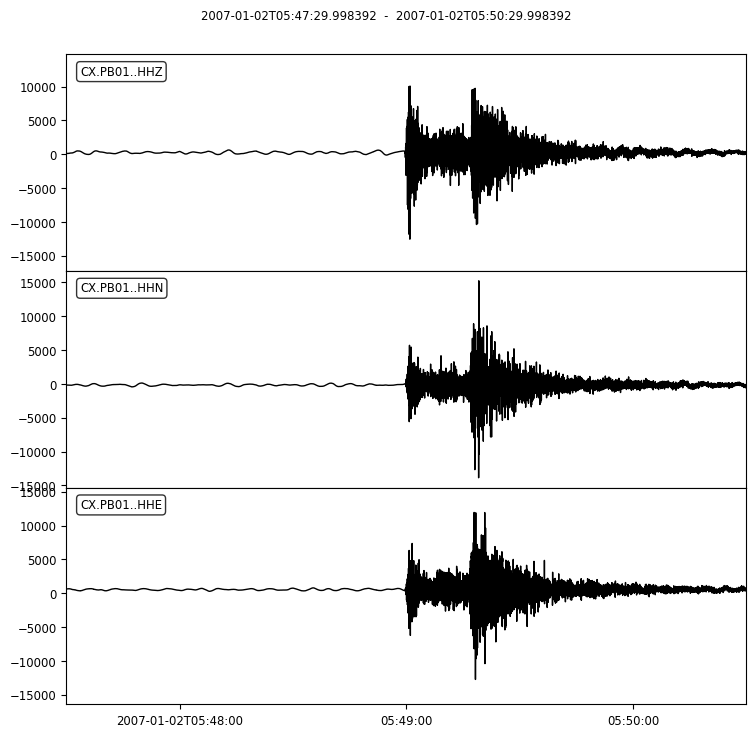

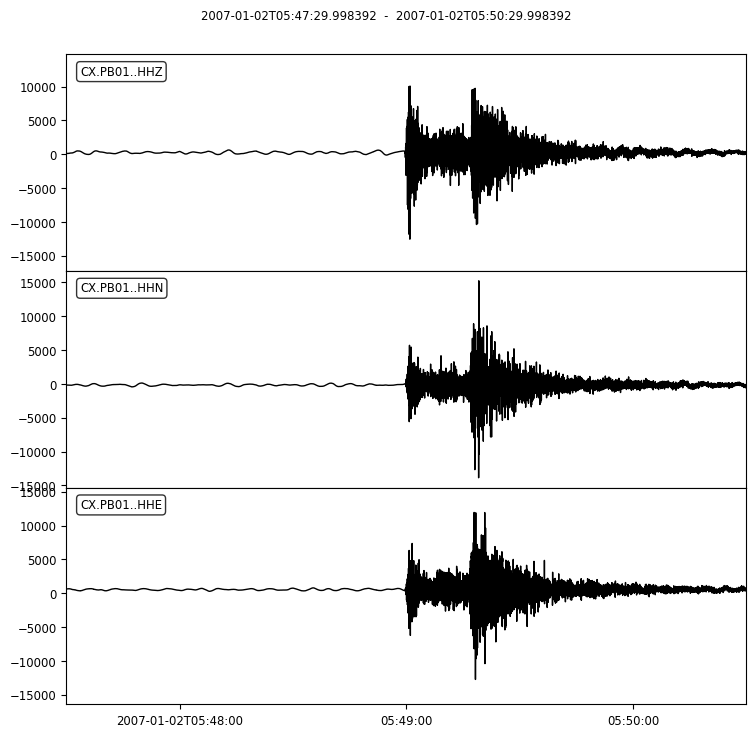

In [12]:
stream.plot()